In [26]:
import scanpy as sc
import torch
import numpy as np
import scvi
import scipy.sparse as sp
import torch.nn.functional as F
from casestudy_lineage import *
import bound as bd
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))
from model.train_model_multislice_p import *

In [2]:
data_path = 'outputs/GP1/results/rollout_h5ad_gp1'
ckpt_path = 'outputs/GP1/ckpt'
resl_path = 'outputs/GP1/perturb'
lrpr_path = 'data/lrpairs/human/LR_pairs.csv'
diff_path = 'Tutorial/GP1/diff_map.csv'
sta1_path = 'outputs/GP1/ckpt/protein_test/normal_to_cancer/checkpoints/best.pt'
sta2_path = 'outputs/GP1/ckpt/policy_ckpt_gp1/policy_normal_to_cancer.pt'

In [3]:
route_ids=['normal', 'cancer']
fracs = ['normal_to_cancer']
seg_key = "normal_to_cancer"
steps = 100

In [4]:
stage1_ckpt = torch.load(sta1_path, weights_only=False)
stage2_ckpt = torch.load(sta2_path, weights_only=False)
print(stage1_ckpt.keys())
print(stage2_ckpt.keys())

dict_keys(['epoch', 'best', 'net', 'opt', 'global_norm', 'wfr_hparams', 'ode_hparams', 'guide_hparams', 'loss_hparams'])
dict_keys(['epoch', 'model_state', 'alpha_state', 'best_reward', 'grid_size', 'advect_latent', 'T', 'use_lr', 'policy_args', 'alpha_args'])


In [5]:
model_dir = f"outputs/GP1/ckpt/scvi/scanvi"
model = scvi.model.SCANVI.load(model_dir)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /home/zhouyj/project/src/GP1_ckpt/scvi/scanvi/model.pt already downloaded                            


In [6]:
gene_list = ['ALDH3A1']
print(gene_list)

['ALDH3A1']


In [7]:
adata_ori = sc.read_h5ad("data/GP1/processed/GP1.h5ad")
adata_ori

AnnData object with n_obs × n_vars = 391 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', 'state', 'tissue_side', 'status', 'source', 'cx_aligned', 'cy_aligned'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'X_pca', 'X_scanVI', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'

In [8]:
adata_nor = adata_ori[adata_ori.obs['status']=='normal']
adata_can = adata_ori[adata_ori.obs['status']=='cancer']
print(adata_nor)
print(adata_can)

View of AnnData object with n_obs × n_vars = 145 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', 'state', 'tissue_side', 'status', 'source', 'cx_aligned', 'cy_aligned'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'X_pca', 'X_scanVI', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
View of AnnData object with n_obs × n_vars = 246 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', 'state', 'tissue_side', 'status', 'source', 'cx_aligned', 'cy_aligned'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'X_pca', 'X_scanVI', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'


In [9]:
import numpy as np
from scipy import sparse

def zero_out_high_gene_cells_in_normal(
    adata,
    gene,
    q=0.90,                    # 10%
    status_col="status",
    normal_label="normal",
    expr_source_layer=None,
    target_layer=None,
    copy=False,
):
    ad = adata.copy() if copy else adata

    if gene not in ad.var_names:
        raise ValueError(f"gene {gene!r} not in adata.var_names ")

    gene_idx = ad.var_names.get_loc(gene)

    if expr_source_layer is None:
        Xsrc = ad.X
    else:
        Xsrc = ad.layers[expr_source_layer]

    if sparse.issparse(Xsrc):
        gene_expr = Xsrc[:, gene_idx].toarray().ravel()
    else:
        gene_expr = np.asarray(Xsrc[:, gene_idx]).ravel()

    normal_mask = ad.obs[status_col].astype(str).eq(str(normal_label)).to_numpy()
    gene_expr_nor = gene_expr[normal_mask]

    #  normal internal
    thr = np.quantile(gene_expr_nor, q)
    hit_mask = normal_mask & (gene_expr >= thr)

    cell_idx = np.where(hit_mask)[0]

    if target_layer is None:
        Xtar = ad.X
    else:
        Xtar = ad.layers[target_layer]

    if sparse.issparse(Xtar):
        Xtar = Xtar.tolil(copy=True)
        Xtar[cell_idx, :] = 0
        Xtar = Xtar.tocsr()
    else:
        Xtar = np.array(Xtar, copy=True)
        Xtar[cell_idx, :] = 0

    if target_layer is None:
        ad.X = Xtar
    else:
        ad.layers[target_layer] = Xtar

    print(f"[ok] gene = {gene}")
    print(f"[ok] normal-only threshold q = {q}, value = {thr}")
    print(f"[ok] hit cells = {len(cell_idx)}")

    return ad

In [10]:
adata_pert = zero_out_high_gene_cells_in_normal(
    adata_ori,
    gene="ALDH3A1",
    q=0.70,
    status_col="status",
    normal_label="normal",
    expr_source_layer="counts",
    target_layer=None,
    copy=True
)


[ok] gene = ALDH3A1
[ok] normal-only threshold q = 0.7, value = 15.0
[ok] hit cells = 45


In [11]:
adata_pert.layers["counts"] = adata_pert.layers["counts"].copy()
adata_pert.obs["cluster"] = adata_pert.obs["cluster"].astype(str)

layer_str = adata_pert.obs["cluster"].astype(str)
nor_layers = {"7", "8", "12"}
can_layers = {"1", "6", "9"}

scvi.model.SCANVI.prepare_query_anndata(adata_pert, model, inplace=True)

z_pert = model.get_latent_representation(adata_pert)
adata_pert.obsm["X_scanvi_pert"] = z_pert

INFO     Found 100.0% reference vars in query data.                                                                
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [12]:
adata_pert

AnnData object with n_obs × n_vars = 391 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', 'state', 'tissue_side', 'status', 'source', 'cx_aligned', 'cy_aligned', '_scvi_batch', '_scvi_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_scanVI', 'X_umap', 'spatial', 'X_scanvi_pert'
    varm: 'PCs'
    layers: 'counts'

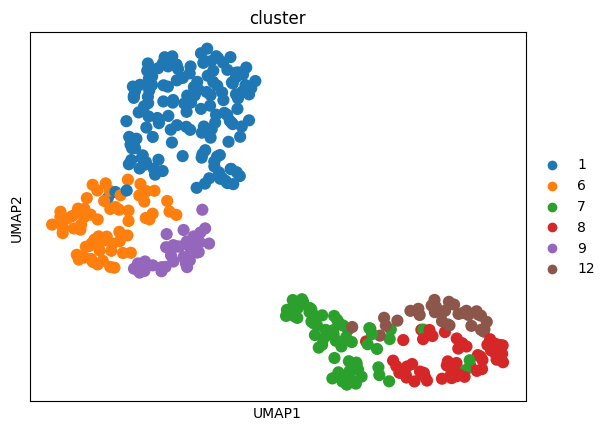

In [13]:
sc.pp.neighbors(adata_ori, use_rep='X_scanVI')
sc.tl.umap(adata_ori)
sc.pl.umap(adata_ori, color='cluster')

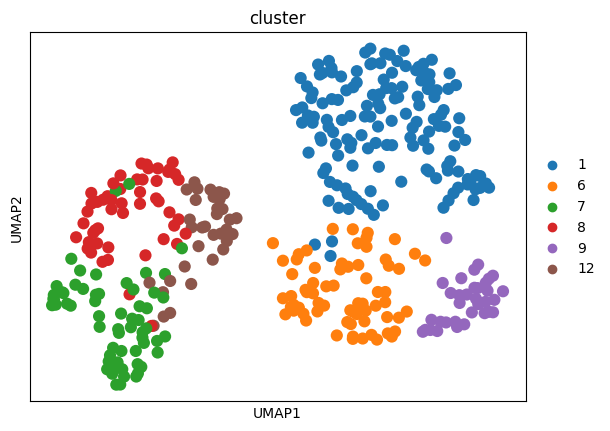

In [14]:
sc.pp.neighbors(adata_pert, use_rep="X_scanvi_pert")
sc.tl.umap(adata_pert)
sc.pl.umap(adata_pert, color = 'cluster')

In [15]:
import numpy as np
import pandas as pd
from scipy import sparse

def mark_cells_to_remove(
    adata,
    gene,
    *,
    status_col="status",
    normal_label="normal",
    source_layer="counts",
    remove_col="remove_from_system",
    thr_mode="gt0",      # "gt0" or "quantile"
    q=0.90,              #  thr_mode="quantile" 
    copy=False,
):
    ad = adata.copy() if copy else adata

    if gene not in ad.var_names:
        raise ValueError(f"{gene!r} not in var_names ")

    if source_layer is None:
        X = ad.X
    else:
        if source_layer not in ad.layers:
            raise ValueError(f"{source_layer!r} not in adata.layers ")
        X = ad.layers[source_layer]

    gidx = ad.var_names.get_loc(gene)
    if sparse.issparse(X):
        gexpr = X[:, gidx].toarray().ravel()
    else:
        gexpr = np.asarray(X[:, gidx]).ravel()

    normal_mask = ad.obs[status_col].astype(str).eq(str(normal_label)).to_numpy()

    if thr_mode == "gt0":
        hit = normal_mask & (gexpr > 0)
        thr = 0.0
    elif thr_mode == "quantile":
        thr = float(np.quantile(gexpr[normal_mask], q))
        hit = normal_mask & (gexpr >= thr)
    else:
        raise ValueError("thr_mode must be 'gt0'  'quantile'")

    ad.obs[remove_col] = hit
    print(f"[ok] gene = {gene}")
    print(f"[ok] remove cells = {int(hit.sum())}")
    print(f"[ok] threshold = {thr:.6f}")
    return ad

In [16]:
adata_marked = mark_cells_to_remove(
    adata_pert,                 #  adata_ori
    gene="ALDH3A1",
    status_col="status",
    normal_label="normal",
    source_layer="counts",
    remove_col="remove_from_system",
    thr_mode="quantile",             #  quantile
    copy=True,
    q=0.70,
)

[ok] gene = ALDH3A1
[ok] remove cells = 45
[ok] threshold = 15.000000


In [17]:
remove_col = "remove_from_system"

adata_sim = adata_marked[~adata_marked.obs[remove_col].to_numpy()].copy()

print("original cell count:", adata_marked.n_obs)
print("simulation cell count:", adata_sim.n_obs)
print("removed cell count:", int(adata_marked.obs[remove_col].sum()))

原始细胞数: 391
仿真使用细胞数: 346
被移除细胞数: 45


In [18]:
adata_sim

AnnData object with n_obs × n_vars = 346 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', 'state', 'tissue_side', 'status', 'source', 'cx_aligned', 'cy_aligned', '_scvi_batch', '_scvi_labels', 'remove_from_system'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'cluster_colors'
    obsm: 'X_pca', 'X_scanVI', 'X_umap', 'spatial', 'X_scanvi_pert'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [19]:
sim_h5ad = "outputs/GP1/perturb/adata_sim_removed_ALDH3A1.h5ad"
adata_sim.write_h5ad(sim_h5ad)

In [94]:
def _to_dense_float32(X):
    if sp.issparse(X):
        X = X.toarray()
    X = np.asarray(X, dtype=np.float32)
    if np.isnan(X).any() or np.isinf(X).any():
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X

def _to_torch(x, device, dtype=torch.float32):
    if isinstance(x, torch.Tensor):
        return x.to(device=device, dtype=dtype)
    return torch.as_tensor(np.asarray(x), device=device, dtype=dtype)

def _get_latent_np(adata, model=None, latent_layer="X_scanVI"):
    if model is not None:
        Z = model.get_latent_representation(adata=adata)
        return np.asarray(Z, dtype=np.float32)
    if latent_layer is not None:
        if latent_layer in getattr(adata, "obsm", {}):
            return _to_dense_float32(adata.obsm[latent_layer])
        if latent_layer in getattr(adata, "layers", {}):
            return _to_dense_float32(adata.layers[latent_layer])
    return _to_dense_float32(adata.X)

def _get_library_torch(adata, device, dtype=torch.float32, lib_layer="counts"):
    X = adata.layers[lib_layer] if (lib_layer is not None and lib_layer in adata.layers) else adata.X
    if sp.issparse(X):
        s = np.ravel(X.sum(axis=1)).astype(np.float32)
    else:
        s = np.asarray(X.sum(axis=1), dtype=np.float32).ravel()
    return torch.as_tensor(s, device=device, dtype=dtype).clamp_min(1e-12)

@torch.no_grad()
def infer_stage1_from_ckpt(
    ckpt_path,
    adata_src,
    adata_tgt,
    *,
    model=None,
    x_key="cx_aligned",
    y_key="cy_aligned",
    latent_layer="X_scanVI",
    lib_layer="counts",
    guide_eps=0.01,
    lam_context=0.0,
    cell_type_key="cluster",
    var_correction=False,
    device="cuda:0",
    max_num_steps=20000,
    residual_scale_x=0.20,
    residual_scale_f=0.05,
    residual_scale_s=0.05,
    verbose=False,
):
    device = torch.device(device)
    dtype = torch.float32
    ckpt = torch.load(ckpt_path, map_location=device)

    ode_hparams = ckpt["ode_hparams"]
    guide_hparams = ckpt["guide_hparams"]
    wfr_hparams = ckpt["wfr_hparams"]
    norm_stats = ckpt["global_norm"]

    xy_mu = torch.as_tensor(norm_stats["xy_mu"], device=device, dtype=dtype)
    xy_s = torch.as_tensor(norm_stats["xy_s"], device=device, dtype=dtype).clamp_min(1e-12)
    f_mu = torch.as_tensor(norm_stats["f_mu"], device=device, dtype=dtype)
    f_std = torch.as_tensor(norm_stats["f_std"], device=device, dtype=dtype).clamp_min(1e-12)

    def scale_x(x): return (x - xy_mu) / xy_s
    def scale_f(f): return (f - f_mu) / f_std
    def unscale_x(x): return x * xy_s + xy_mu
    def unscale_f(f): return f * f_std + f_mu

    coords0 = torch.as_tensor(np.asarray(adata_src.obs[[x_key, y_key]], dtype=np.float32), device=device, dtype=dtype)
    coords_tgt = torch.as_tensor(np.asarray(adata_tgt.obs[[x_key, y_key]], dtype=np.float32), device=device, dtype=dtype)
    Z0 = torch.as_tensor(_get_latent_np(adata_src, model=model, latent_layer=latent_layer), device=device, dtype=dtype)
    Zt = torch.as_tensor(_get_latent_np(adata_tgt, model=model, latent_layer=latent_layer), device=device, dtype=dtype)
    lib0 = _get_library_torch(adata_src, device=device, dtype=dtype, lib_layer=lib_layer)
    lib_tgt = _get_library_torch(adata_tgt, device=device, dtype=dtype, lib_layer=lib_layer)

    coords0_n = scale_x(coords0)
    coords_tgt_n = scale_x(coords_tgt)
    Z0_n = scale_f(Z0)
    Zt_n = scale_f(Zt)

    if lam_context > 0:
        neighbor_src, neighbor_tgt = get_neighbor_features(adata_src, adata_tgt, cell_type_key=cell_type_key)
        ctx0 = F.normalize(_to_torch(neighbor_src, device=device, dtype=dtype), p=2, dim=1)
        ctxT = F.normalize(_to_torch(neighbor_tgt, device=device, dtype=dtype), p=2, dim=1)
    else:
        ctx0, ctxT = None, None

    guide_fn = build_guide(
        coords0_n, Z0_n, lib0,
        coords_tgt_n, Zt_n, lib_tgt,
        eps=guide_hparams.get("eps", guide_eps),
        tau=wfr_hparams["tau"],
        lam_x=wfr_hparams["lam_x"],
        lam_f=wfr_hparams["lam_f"],
        # topk=guide_hparams["topk"],
        topk=3600,
        temp=guide_hparams["temp"],
        schedule=guide_hparams["schedule"],
        ctx0=ctx0, ctxT=ctxT, lam_context=lam_context,
        var_correction=var_correction,
        verbose=verbose,
    )

    net = ResidualDynamicsNet(
        latent_dim=int(ode_hparams["latent_dim"]),
        hidden=int(ode_hparams["hidden"]),
        residual_scale_x=residual_scale_x,
        residual_scale_f=residual_scale_f,
        residual_scale_s=residual_scale_s,
    ).to(device)
    net.load_state_dict(ckpt["net"])
    net.eval()

    guide_cache = GuideCache(guide_fn, n=int(ode_hparams["n_cache"]), device=device, dtype=dtype)
    func = FusedODEFunc(guide_cache, net).to(device)
    func.eval()

    t_eval, xs, qs, ss = rollout_neuralode_dopri5(
        func,
        coords0_n, Z0_n, lib0,
        steps=int(ode_hparams["steps"]),
        rtol=float(ode_hparams["rtol"]),
        atol=float(ode_hparams["atol"]),
        max_num_steps=int(max_num_steps),
    )

    x1_n, q1_n, s1 = xs[-1], qs[-1], ss[-1]
    x1 = unscale_x(x1_n)
    q1 = unscale_f(q1_n)
    m1 = torch.exp(s1.reshape(-1))

    return {
        "ckpt": ckpt,
        "t_eval": t_eval,
        "coords0": coords0, "coords_tgt": coords_tgt,
        "coords0_norm": coords0_n, "coords_tgt_norm": coords_tgt_n,
        "Z0": Z0, "Zt": Zt,
        "Z0_norm": Z0_n, "Zt_norm": Zt_n,
        "lib0": lib0, "lib_tgt": lib_tgt,
        "xs_norm": xs, "qs_norm": qs, "ss": ss,
        "x1_norm": x1_n, "q1_norm": q1_n,
        "x1": x1, "q1": q1, "m1": m1,
        "guide_fn": guide_fn,
        "net": net,
        "func": func,
    }

In [24]:
adata_src = adata_sim[adata_sim.obs['status']=='normal']
adata_tgt = adata_sim[adata_sim.obs['status']=='cancer']
print(adata_src)
print(adata_tgt)

View of AnnData object with n_obs × n_vars = 100 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', 'state', 'tissue_side', 'status', 'source', 'cx_aligned', 'cy_aligned', '_scvi_batch', '_scvi_labels', 'remove_from_system'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'cluster_colors'
    obsm: 'X_pca', 'X_scanVI', 'X_umap', 'spatial', 'X_scanvi_pert'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'
View of AnnData object with n_obs × n_vars = 246 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', 'state', 'tissue_side', 'status', 'source', 'cx_aligned', 'cy_aligned', '_scvi_batch', '_scvi_labels', 'remove_from_system'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'cluster_colors'
    obsm: 'X_pca', 'X_scanVI', 'X_umap', 'spatial', 'X_scanvi_pert'
    varm: 'PCs'
    layers: 'counts'
    obsp: 

In [28]:
def _to_dense_float32(X):
    if sp.issparse(X):
        X = X.toarray()
    X = np.asarray(X, dtype=np.float32)
    if np.isnan(X).any() or np.isinf(X).any():
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X

def _to_torch(x, device, dtype=torch.float32):
    if isinstance(x, torch.Tensor):
        return x.to(device=device, dtype=dtype)
    return torch.as_tensor(np.asarray(x), device=device, dtype=dtype)

def _get_latent_np(adata, model=None, latent_layer="X_scanVI"):
    if model is not None:
        Z = model.get_latent_representation(adata=adata)
        return np.asarray(Z, dtype=np.float32)
    if latent_layer is not None:
        if latent_layer in getattr(adata, "obsm", {}):
            return _to_dense_float32(adata.obsm[latent_layer])
        if latent_layer in getattr(adata, "layers", {}):
            return _to_dense_float32(adata.layers[latent_layer])
    return _to_dense_float32(adata.X)

def _get_library_torch(adata, device, dtype=torch.float32, lib_layer="counts"):
    X = adata.layers[lib_layer] if (lib_layer is not None and lib_layer in adata.layers) else adata.X
    if sp.issparse(X):
        s = np.ravel(X.sum(axis=1)).astype(np.float32)
    else:
        s = np.asarray(X.sum(axis=1), dtype=np.float32).ravel()
    return torch.as_tensor(s, device=device, dtype=dtype).clamp_min(1e-12)

@torch.no_grad()
def infer_stage1_from_ckpt(
    ckpt_path,
    adata_src,
    adata_tgt,
    *,
    model=None,
    x_key="cx_aligned",
    y_key="cy_aligned",
    latent_layer="X_scanVI",
    lib_layer="counts",
    guide_eps=0.01,
    lam_context=0.0,
    cell_type_key="cluster",
    var_correction=False,
    device="cuda:0",
    max_num_steps=20000,
    residual_scale_x=0.20,
    residual_scale_f=0.05,
    residual_scale_s=0.05,
    verbose=False,
):
    device = torch.device(device)
    dtype = torch.float32
    ckpt = torch.load(ckpt_path, map_location=device)

    ode_hparams = ckpt["ode_hparams"]
    guide_hparams = ckpt["guide_hparams"]
    wfr_hparams = ckpt["wfr_hparams"]
    norm_stats = ckpt["global_norm"]

    xy_mu = torch.as_tensor(norm_stats["xy_mu"], device=device, dtype=dtype)
    xy_s = torch.as_tensor(norm_stats["xy_s"], device=device, dtype=dtype).clamp_min(1e-12)
    f_mu = torch.as_tensor(norm_stats["f_mu"], device=device, dtype=dtype)
    f_std = torch.as_tensor(norm_stats["f_std"], device=device, dtype=dtype).clamp_min(1e-12)

    def scale_x(x): return (x - xy_mu) / xy_s
    def scale_f(f): return (f - f_mu) / f_std
    def unscale_x(x): return x * xy_s + xy_mu
    def unscale_f(f): return f * f_std + f_mu

    coords0 = torch.as_tensor(np.asarray(adata_src.obs[[x_key, y_key]], dtype=np.float32), device=device, dtype=dtype)
    coords_tgt = torch.as_tensor(np.asarray(adata_tgt.obs[[x_key, y_key]], dtype=np.float32), device=device, dtype=dtype)
    Z0 = torch.as_tensor(_get_latent_np(adata_src, model=model, latent_layer=latent_layer), device=device, dtype=dtype)
    Zt = torch.as_tensor(_get_latent_np(adata_tgt, model=model, latent_layer=latent_layer), device=device, dtype=dtype)
    lib0 = _get_library_torch(adata_src, device=device, dtype=dtype, lib_layer=lib_layer)
    lib_tgt = _get_library_torch(adata_tgt, device=device, dtype=dtype, lib_layer=lib_layer)

    coords0_n = scale_x(coords0)
    coords_tgt_n = scale_x(coords_tgt)
    Z0_n = scale_f(Z0)
    Zt_n = scale_f(Zt)

    if lam_context > 0:
        neighbor_src, neighbor_tgt = get_neighbor_features(adata_src, adata_tgt, cell_type_key=cell_type_key)
        ctx0 = F.normalize(_to_torch(neighbor_src, device=device, dtype=dtype), p=2, dim=1)
        ctxT = F.normalize(_to_torch(neighbor_tgt, device=device, dtype=dtype), p=2, dim=1)
    else:
        ctx0, ctxT = None, None

    guide_fn = build_guide(
        coords0_n, Z0_n, lib0,
        coords_tgt_n, Zt_n, lib_tgt,
        eps=guide_hparams.get("eps", guide_eps),
        tau=wfr_hparams["tau"],
        lam_x=wfr_hparams["lam_x"],
        lam_f=wfr_hparams["lam_f"],
        # topk=guide_hparams["topk"],
        topk=3600,
        temp=guide_hparams["temp"],
        schedule=guide_hparams["schedule"],
        ctx0=ctx0, ctxT=ctxT, lam_context=lam_context,
        var_correction=var_correction,
        verbose=verbose,
    )

    net = ResidualDynamicsNet(
        latent_dim=int(ode_hparams["latent_dim"]),
        hidden=int(ode_hparams["hidden"]),
        residual_scale_x=residual_scale_x,
        residual_scale_f=residual_scale_f,
        residual_scale_s=residual_scale_s,
    ).to(device)
    net.load_state_dict(ckpt["net"])
    net.eval()

    guide_cache = GuideCache(guide_fn, n=int(ode_hparams["n_cache"]), device=device, dtype=dtype)
    func = FusedODEFunc(guide_cache, net).to(device)
    func.eval()

    t_eval, xs, qs, ss = rollout_neuralode_dopri5(
        func,
        coords0_n, Z0_n, lib0,
        steps=int(ode_hparams["steps"]),
        rtol=float(ode_hparams["rtol"]),
        atol=float(ode_hparams["atol"]),
        max_num_steps=int(max_num_steps),
    )

    x1_n, q1_n, s1 = xs[-1], qs[-1], ss[-1]
    x1 = unscale_x(x1_n)
    q1 = unscale_f(q1_n)
    m1 = torch.exp(s1.reshape(-1))

    return {
        "ckpt": ckpt,
        "t_eval": t_eval,
        "coords0": coords0, "coords_tgt": coords_tgt,
        "coords0_norm": coords0_n, "coords_tgt_norm": coords_tgt_n,
        "Z0": Z0, "Zt": Zt,
        "Z0_norm": Z0_n, "Zt_norm": Zt_n,
        "lib0": lib0, "lib_tgt": lib_tgt,
        "xs_norm": xs, "qs_norm": qs, "ss": ss,
        "x1_norm": x1_n, "q1_norm": q1_n,
        "x1": x1, "q1": q1, "m1": m1,
        "guide_fn": guide_fn,
        "net": net,
        "func": func,
    }

In [29]:
res1_zs = infer_stage1_from_ckpt(
    ckpt_path=f"{ckpt_path}/protein_test/normal_to_cancer/checkpoints/best.pt",
    adata_src=adata_src,
    adata_tgt=adata_tgt,
    model=model,
    x_key="cx_aligned",
    y_key="cy_aligned",
    latent_layer="X_scanvi_pert",
    lib_layer="counts",
    guide_eps=0.01,
    lam_context=0.0,
    cell_type_key="_clone_s",
    var_correction=False,
    device="cuda:0",
)

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


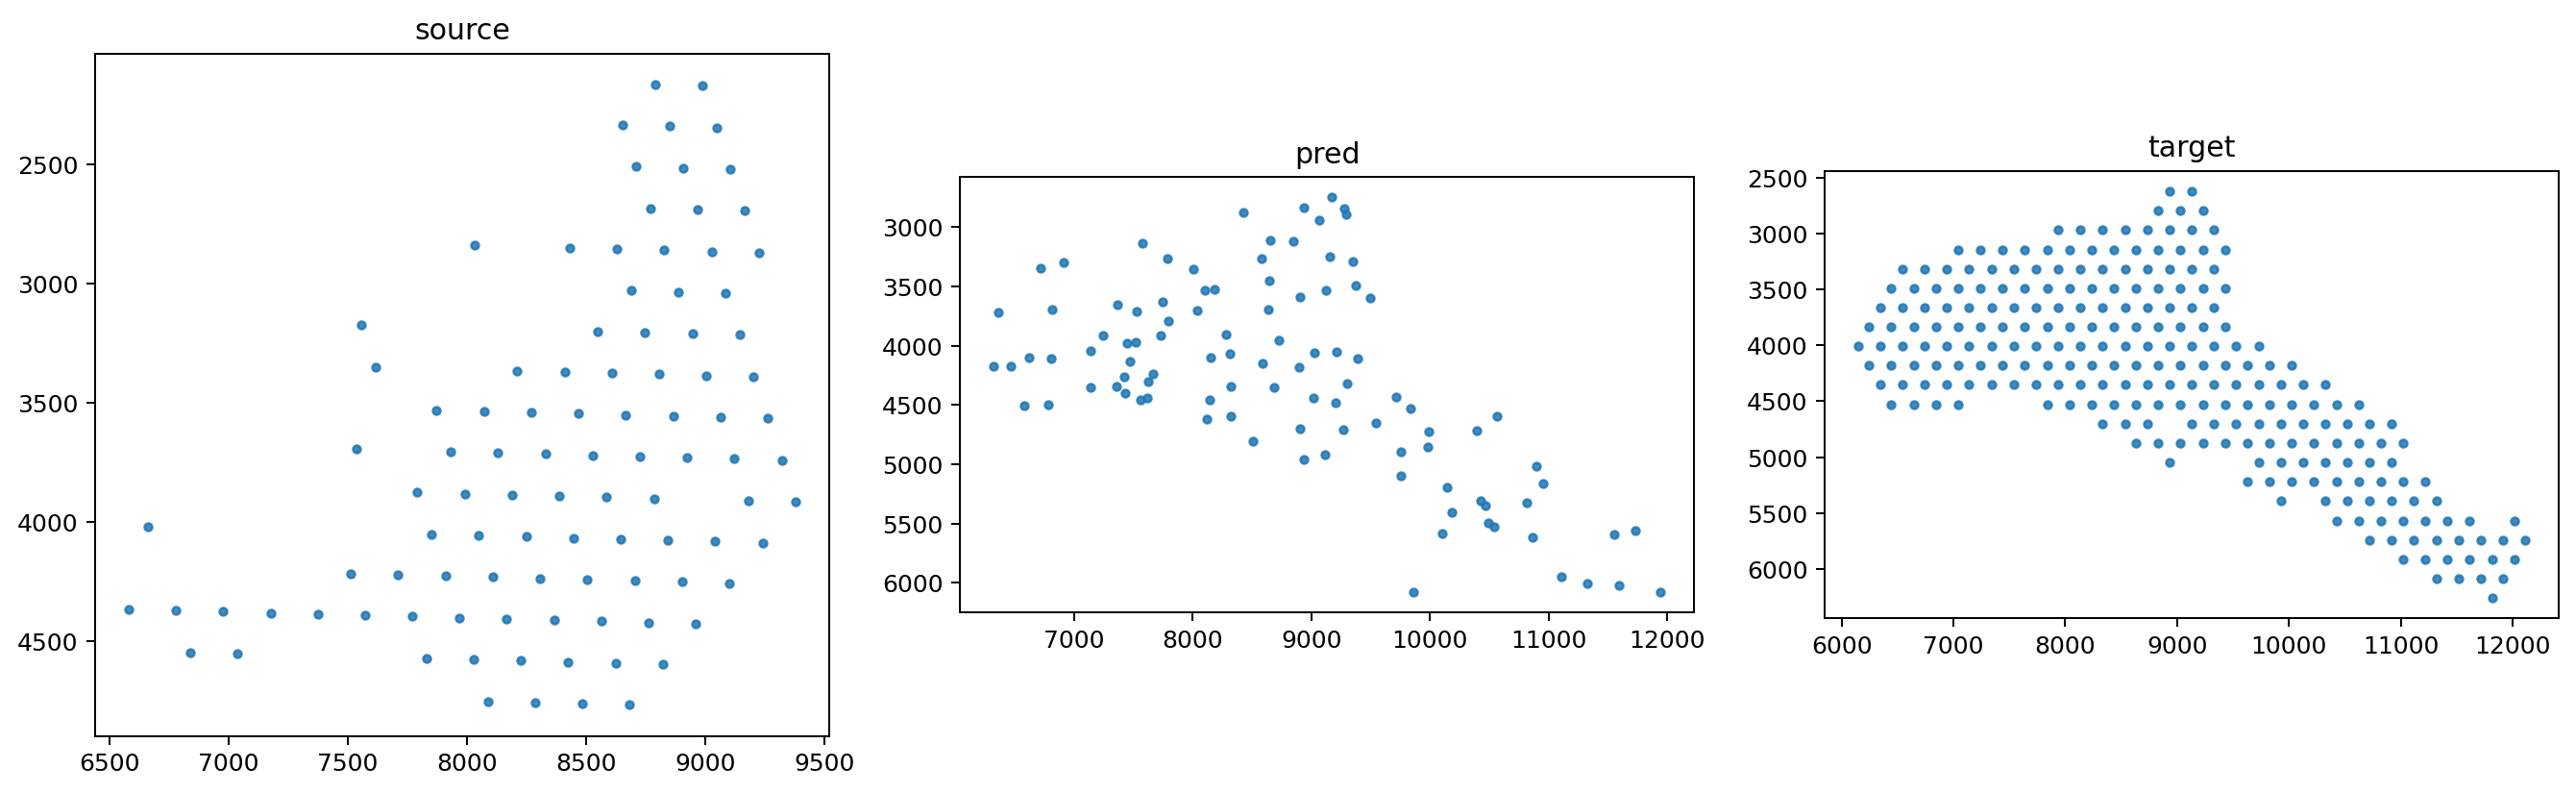

In [30]:
import numpy as np
import matplotlib.pyplot as plt

X0 = res1_zs["coords0"].detach().cpu().numpy()
X1 = res1_zs["x1"].detach().cpu().numpy()
XT = res1_zs["coords_tgt"].detach().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=180)

axes[0].scatter(X0[:, 0], X0[:, 1], s=10, alpha=0.85)
axes[0].set_title("source")

axes[1].scatter(X1[:, 0], X1[:, 1], s=10, alpha=0.85)
axes[1].set_title("pred")

axes[2].scatter(XT[:, 0], XT[:, 1], s=10, alpha=0.85)
axes[2].set_title("target")

for ax in axes:
    ax.set_aspect("equal")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [31]:
import copy
import torch

def _filter_kwargs(cls, kw):
    sig = inspect.signature(cls.__init__); ok = set(sig.parameters.keys()); ok.discard("self")
    return {k: v for k, v in kw.items() if k in ok}

def _clone_state_dict_for_return(state):
    out = {}
    for k, v in state.items():
        if isinstance(v, torch.Tensor):
            out[k] = v.detach().clone()
        else:
            out[k] = copy.deepcopy(v)
    return out

@torch.no_grad()
def infer_stage2_from_ckpt(
    ckpt_path, *,
    state0, target_state, shells_norm,
    coords_seq_torch, Z_seq_torch, base_layers0,
    grid_cache_np, grid_cache_dev, B_step_layer, D_step_layer,
    recompute_lr_fn, policy_cls, env_cls,
    device="cuda:0",
    T=None, n_layers=None, H=None, W=None,
    USE_LR=None, ADVECT_LATENT=None, hidden_dim=None,
    shell_need_cap=3,
    TAU_BIRTH=1.0, TAU_DEATH=1.0, TAU_DIFF=1.0, LATENT_NOISE_SCALE=0.01,
    diff_tgt_idx=None, diff_tgt_w=None,
    seed_base=0,
    return_history=True,
):
    device = torch.device(device)
    ckpt = torch.load(ckpt_path, map_location=device)

    p_args = dict(ckpt.get("policy_args", {}))
    a_args = dict(ckpt.get("alpha_args", {}))

    if USE_LR is None:
        USE_LR = bool(ckpt.get("use_lr", p_args.get("use_lr", True)))
    if ADVECT_LATENT is None:
        ADVECT_LATENT = bool(ckpt.get("advect_latent", True))
    if T is None:
        T = int(ckpt["T"])
    if n_layers is None:
        n_layers = int(p_args["n_layers"])
    if hidden_dim is None:
        hidden_dim = int(p_args.get("hidden_dim", 128))
    if H is None or W is None:
        H_ck, W_ck = ckpt["grid_size"]
        H = int(H_ck if H is None else H)
        W = int(W_ck if W is None else W)

    p_args["n_layers"] = int(n_layers)
    p_args["use_lr"] = bool(USE_LR)
    p_args["hidden_dim"] = int(hidden_dim)
    a_args["use_lr"] = bool(USE_LR)

    policy_net = policy_cls(**_filter_kwargs(policy_cls, p_args)).to(device)
    alpha_net = AlphaTransitionNet(**a_args).to(device)

    policy_net.load_state_dict(ckpt["model_state"])
    alpha_net.load_state_dict(ckpt["alpha_state"])
    policy_net.eval()
    alpha_net.eval()

    env = env_cls(
        state0=state0,
        target_state=target_state,
        device=device,
        alpha_net=alpha_net,
        base_coords_seq=coords_seq_torch,
        base_Z_seq=Z_seq_torch,
        base_layers0=base_layers0,
        grid_cache_np=grid_cache_np,
        grid_cache_dev=grid_cache_dev,
        shells_norm=shells_norm,
        T=int(T),
        n_layers=int(n_layers),
        H=int(H),
        W=int(W),
        recompute_lr_fn=recompute_lr_fn,
        t0=0,
        shell_need_cap=int(shell_need_cap),
        use_lr=bool(USE_LR),
        diff_tgt_idx=diff_tgt_idx,
        diff_tgt_w=diff_tgt_w,
    )

    history = {"state": [], "logp": [], "ent": []} if return_history else None

    if return_history:
        history["state"].append(_clone_state_dict_for_return(env.state))

    for t in range(int(T)):
        step_out = env.step(
            policy_net,
            birth_quota_layer=B_step_layer[t],
            death_quota_layer=D_step_layer[t],
            dir_step=+1,
            advect_latent=bool(ADVECT_LATENT),
            seed_step=int(seed_base + t),
            TAU_BIRTH=float(TAU_BIRTH),
            TAU_DEATH=float(TAU_DEATH),
            TAU_DIFF=float(TAU_DIFF),
            LATENT_NOISE_SCALE=float(LATENT_NOISE_SCALE),
        )
        if isinstance(step_out, tuple) and len(step_out) == 2:
            logp, ent = step_out
        else:
            logp, ent = None, None

        if return_history:
            history["logp"].append(None if logp is None else float(logp.detach().cpu().item()))
            history["ent"].append(None if ent is None else float(ent.detach().cpu().item()))
            history["state"].append(_clone_state_dict_for_return(env.state))

    out = {
        "ckpt": ckpt,
        "policy": policy_net,
        "alpha_net": alpha_net,
        "env": env,
        "state_final": _clone_state_dict_for_return(env.state),
        "best_reward": float(ckpt.get("best_reward", float("nan"))),
        "T": int(T),
        "H": int(H),
        "W": int(W),
        "n_layers": int(n_layers),
        "use_lr": bool(USE_LR),
        "advect_latent": bool(ADVECT_LATENT),
    }
    if return_history:
        out["history"] = history
    return out

In [32]:
def prepare_one_stage_from_res1(
    ctx, cfg: StageCfg, *, res1_zs, ad_src, ad_tgt,
    layer_col: str, sample_key: str = "sample",
    x_key: str = "cx_rigid_aligned", y_key: str = "cy_rigid_aligned",
    **kwargs
):
    coords_seq_override = [x.detach() for x in res1_zs["xs_norm"]]
    Z_seq_override = [z.detach() for z in res1_zs["qs_norm"]]
    mass_frames_override = [torch.exp(s.detach().reshape(-1)).cpu().numpy().astype(np.float32) for s in res1_zs["ss"]]
    return prepare_one_stage(
        ctx, cfg, layer_col=layer_col, sample_key=sample_key, x_key=x_key, y_key=y_key,
        ad_src_override=ad_src, ad_tgt_override=ad_tgt,
        coords_seq_override=coords_seq_override,
        Z_seq_override=Z_seq_override,
        mass_frames_override=mass_frames_override,
        **kwargs
    )

In [33]:
def _infer_policy_args_smart(in_features: int, n_layers: int, hidden_dim: int):
    for use_lr in (False, True):
        for use_t in (False, True):
            d = 3 + (1 if use_lr else 0) + (1 if use_t else 0)
            if d == in_features:
                return {"n_layers": n_layers, "use_lr": use_lr, "use_t": use_t, "hidden_dim": hidden_dim, "learn_eta0": True, "eta0_init": 0.2}
    raise RuntimeError(f"cannot {in_features}  GrowthPolicyNet  (new-mode).")

def _load_policy_and_alpha_net(s2, ckpt_path, *, n_layers, device, latent_dim=None):
    ckpt = torch.load(ckpt_path, map_location=device)

    sd = ckpt.get("model_state", None) or ckpt.get("state_dict", None) or ckpt

    # ---- load policy ----
    policy_args = ckpt.get("policy_args", None)
    if policy_args is not None:
        args = dict(policy_args)
        args["n_layers"] = int(n_layers)
    else:
        if "net.0.weight" in sd:
            w = sd["net.0.weight"]
            in_features = int(w.shape[1])
            hidden_dim = int(w.shape[0])
        else:
            keys = list(sd.keys())
            w = sd[keys[0]]
            in_features = int(w.shape[1])
            hidden_dim = int(w.shape[0])
        args = _infer_policy_args_smart(in_features, n_layers, hidden_dim)

    PolicyCls = getattr(s2, "PolicyNet", None)
    if PolicyCls is None:
        PolicyCls = getattr(s2, "GrowthPolicyNet")

    policy_net = PolicyCls(**_filter_kwargs(PolicyCls, args)).to(device)
    policy_net.load_state_dict(sd, strict=False)
    policy_net.eval()

    # ---- load alpha ----
    alpha_args = ckpt.get("alpha_args", None)
    if alpha_args is not None:
        alpha_args = dict(alpha_args)
        alpha_args.pop("latent_dim", None)   
    else:
        alpha_args = {
            "use_lr": bool(ckpt.get("use_lr", True)),
            "hidden_dim": 128,
        }

    alpha_net = AlphaTransitionNet(**_filter_kwargs(AlphaTransitionNet, alpha_args)).to(device)

    if "alpha_state" in ckpt:
        alpha_net.load_state_dict(ckpt["alpha_state"], strict=False)
    else:
        raise KeyError("ckpt missing alpha_state,cannot alpha_net")

    alpha_net.eval()
    return policy_net, alpha_net


In [34]:
import copy, inspect, torch

def _filter_kwargs(cls, kw):
    sig = inspect.signature(cls.__init__)
    ok = set(sig.parameters.keys())
    ok.discard("self")
    return {k: v for k, v in kw.items() if k in ok}

@torch.no_grad()
def infer_one_stage_from_pack(
    *, pack: StagePack, ckpt_path: str, device,
    policy_cls, alpha_cls, env_cls,
    USE_LR=None, ADVECT_LATENT=None,
    TAU_BIRTH=1.0, TAU_DEATH=1.0, TAU_DIFF=1.0,
    LATENT_NOISE_SCALE=0.01,
    return_history=True, seed_base=2025,
):
    device = torch.device(device)
    ckpt = torch.load(ckpt_path, map_location=device)

    p_args = dict(ckpt.get("policy_args", {}))
    a_args = dict(ckpt.get("alpha_args", {}))

    if USE_LR is None:
        USE_LR = bool(ckpt.get("use_lr", p_args.get("use_lr", True)))
    if ADVECT_LATENT is None:
        ADVECT_LATENT = bool(ckpt.get("advect_latent", True))

    p_args["n_layers"] = int(pack.n_layers)
    p_args["use_lr"] = bool(USE_LR)
    a_args["use_lr"] = bool(USE_LR)

    policy_net = policy_cls(**_filter_kwargs(policy_cls, p_args)).to(device)
    alpha_net = alpha_cls(**_filter_kwargs(alpha_cls, a_args)).to(device)

    policy_net.load_state_dict(ckpt["model_state"], strict=True)
    alpha_net.load_state_dict(ckpt["alpha_state"], strict=True)

    policy_net.eval()
    alpha_net.eval()

    env = env_cls(
        state0=pack.state0,
        target_state=pack.target_state,
        device=device,
        alpha_net=alpha_net,
        base_coords_seq=pack.coords_seq_torch,
        base_Z_seq=pack.Z_seq_torch,
        base_layers0=pack.base_layers0,
        grid_cache_np=pack.grid_cache_np,
        grid_cache_dev=pack.grid_cache_dev,
        shells_norm=pack.shells_norm,
        T=int(pack.T),
        n_layers=int(pack.n_layers),
        H=int(pack.H),
        W=int(pack.W),
        recompute_lr_fn=pack.recompute_lr_fn,
        t0=0,
        shell_need_cap=int(pack.shell_need_cap),
        use_lr=bool(USE_LR),
        diff_tgt_idx=pack.diff_tgt_idx,
        diff_tgt_w=pack.diff_tgt_w,
    )

    history = {"state": []} if return_history else None
    if return_history:
        history["state"].append({
            k: (v.detach().clone() if torch.is_tensor(v) else copy.deepcopy(v))
            for k, v in env.state.items()
        })

    for t in range(int(pack.T)):
        env.step(
            policy_net,
            birth_quota_layer=pack.B_step_layer[t],
            death_quota_layer=pack.D_step_layer[t],
            dir_step=+1,
            advect_latent=bool(ADVECT_LATENT),
            seed_step=int(seed_base + t),
            TAU_BIRTH=float(TAU_BIRTH),
            TAU_DEATH=float(TAU_DEATH),
            TAU_DIFF=float(TAU_DIFF),
            LATENT_NOISE_SCALE=float(LATENT_NOISE_SCALE),
        )
        if return_history:
            history["state"].append({
                k: (v.detach().clone() if torch.is_tensor(v) else copy.deepcopy(v))
                for k, v in env.state.items()
            })

    out = {
        "ckpt": ckpt,
        "policy": policy_net,
        "alpha_net": alpha_net,
        "env": env,
        "state_final": {
            k: (v.detach().clone() if torch.is_tensor(v) else copy.deepcopy(v))
            for k, v in env.state.items()
        },
    }
    if return_history:
        out["history"] = history
    return out

In [35]:
adata_pert.write_h5ad(f"outputs/GP1/casestudy/adata_pert_ALDH3A1.h5ad")

In [166]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

ctx = build_global_ctx(
    adata_path=sim_h5ad,
    lr_pairs_path=lrpr_path,
    ckpt_3dslice=f"{ckpt_path}/protein_test/normal_to_cancer/checkpoints/best.pt",
    device=device,
    layer_col="cluster",
)

cfg_lower = StageCfg(
    src="normal",
    tgt="cancer",
    out_npz_path=None, 
    bound_dir=f"{resl_path}/bound/normal_to_cancer",
    stat_json=f"{ckpt_path}/exp_decoder/decoder_counts_pair_normal_cancer.json",
    ckpt_path_dec=f"{ckpt_path}/exp_decoder/decoder_counts_pair_normal_cancer.pt",
    scanvi_dir=f"{ckpt_path}/sub_scvi/scanvi",
    diff_csv=diff_path,
    model_type="scanvi",
    use_lr=True,
    lr_source="decoder",
    use_latent=True,
    latent_fallback_obsm="X_scanvi_pert",
    latent_fallback_layer="counts",
    z_csv_offset=0,
    layer_col="cluster",
)

pack_lower = prepare_one_stage_from_res1(
    ctx=ctx,
    cfg=cfg_lower,
    res1_zs=res1_zs,
    ad_src=adata_src,
    ad_tgt=adata_tgt,
    layer_col="cluster",
    sample_key="status",
    x_key="cx_aligned",
    y_key="cy_aligned",
)

res2_zs = infer_one_stage_from_pack(
    pack=pack_lower,
    ckpt_path=f"{ckpt_path}/policy_ckpt_gp1/policy_normal_to_cancer.pt",
    device=device,
    policy_cls=GrowthPolicyNet,
    alpha_cls=AlphaTransitionNet,
    env_cls=SimulationEnv,
    USE_LR=True,
    ADVECT_LATENT=True,
    TAU_BIRTH=1.0,
    TAU_DEATH=1.0,
    TAU_DIFF=1.0,
    LATENT_NOISE_SCALE=0.01,
    return_history=True,
    seed_base=2025,
)

state_final = res2_zs["state_final"]
coords_gen = state_final["coords"]
layers_gen = state_final["layers"]
latent_gen = state_final.get("latent", None)
alpha_gen = state_final["diff_alpha"]

LOADING latent model from: /home/zhouyj/project/src/GP1_ckpt/sub_scvi/scanvi
[Grid] H=32, W=32, H×W=1024
[auto cap] 1 {'src': {'q': 0.9, 'quantile_value': 1.0, 'mean': 1.0, 'max': 1.0, 'n_cells_used': 100}, 'tgt': {'q': 0.9, 'quantile_value': 1.0, 'mean': 1.0086580514907837, 'max': 2.0, 'n_cells_used': 231}, 'cap0': 1, 'capT': 1, 'cap': 1}
[diff] loaded /home/zhouyj/project/src/GP1/diff_map.csv Kmax= 2


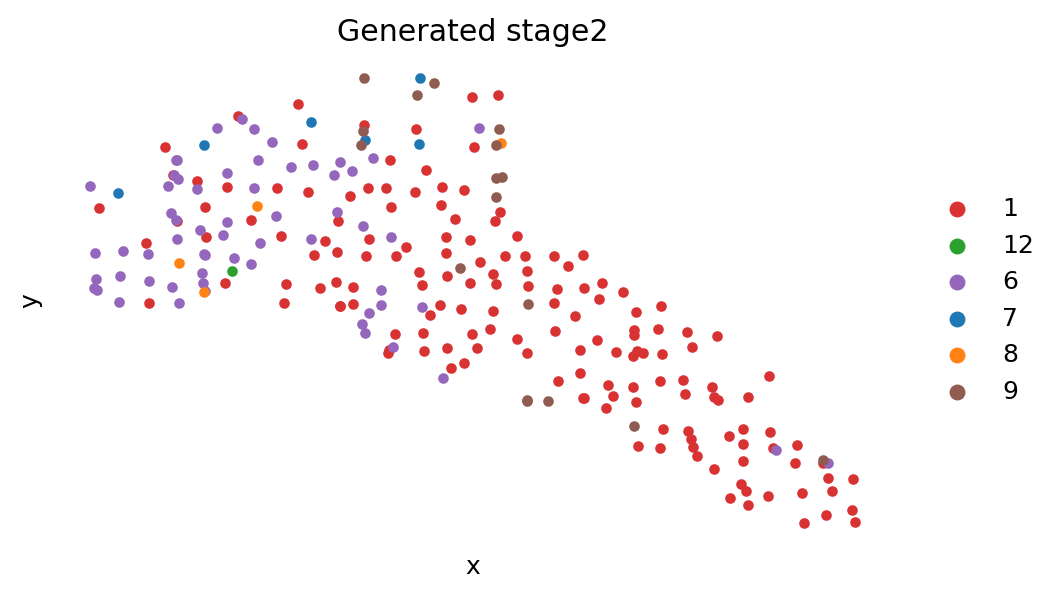

In [167]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# ---------- 1)  numpy ----------
def to_np(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

coords_gen_np = to_np(coords_gen)
layers_gen_np = to_np(layers_gen).astype(int)

# source / target ,
coords_src_np = to_np(pack_lower.state0["coords"])
layers_src_np = to_np(pack_lower.state0["layers"]).astype(int)

coords_tgt_np = to_np(pack_lower.target_state["coords"])
layers_tgt_np = to_np(pack_lower.target_state["layers"]).astype(int)

# ---------- 2) layer idx ->  ----------
if hasattr(ctx, "layers_list") and ctx.layers_list is not None:
    idx_to_layer = {i: str(x) for i, x in enumerate(ctx.layers_list)}
else:
    all_idx = np.unique(np.concatenate([layers_src_np, layers_tgt_np, layers_gen_np]))
    idx_to_layer = {int(i): str(i) for i in all_idx}

layer_name_gen = np.array([idx_to_layer.get(int(i), str(i)) for i in layers_gen_np], dtype=object)
layer_name_src = np.array([idx_to_layer.get(int(i), str(i)) for i in layers_src_np], dtype=object)
layer_name_tgt = np.array([idx_to_layer.get(int(i), str(i)) for i in layers_tgt_np], dtype=object)

# ---------- 3)  ----------
cluster_color_map = {
    "7": "#1F77B4",
    "8": "#FF8214",
    "12": "#2CA02C",
    "1": "#D93233",
    "6": "#9467BD",
    "9": "#905B51",
}

all_names = sorted(set(layer_name_src) | set(layer_name_tgt) | set(layer_name_gen), key=lambda x: (x not in cluster_color_map, x))
fallback_colors = plt.cm.tab20(np.linspace(0, 1, max(20, len(all_names))))
color_map = {}
j = 0
for name in all_names:
    if name in cluster_color_map:
        color_map[name] = cluster_color_map[name]
    else:
        color_map[name] = fallback_colors[j]
        j += 1

# ---------- 4)  ----------
def plot_one(coords, labels, title="", s=16, alpha=0.95, invert_y=True, add_legend=True):
    plt.figure(figsize=(6, 6), dpi=180)
    for lab in all_names:
        m = (labels == lab)
        if np.any(m):
            plt.scatter(coords[m, 0], coords[m, 1], s=s, c=[color_map[lab]], label=lab, alpha=alpha, linewidths=0)
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    if invert_y:
        plt.gca().invert_yaxis()
    plt.gca().set_aspect("equal", adjustable="box")
    plt.xticks([])
    plt.yticks([])
    for spine in plt.gca().spines.values():
        spine.set_visible(False)
    if add_legend:
        plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, markerscale=1.5)
    plt.tight_layout()
    plt.show()

# ---------- 5)  ----------
plot_one(coords_gen_np, layer_name_gen, title="Generated stage2", s=18, alpha=1.0, invert_y=True, add_legend=True)

In [168]:
import numpy as np
import pandas as pd
import torch
import anndata as ad
import scipy.sparse as sp

def _to_np(x):
    if x is None:
        return None
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def build_history_adata_from_res2(res2_zs, ctx=None, include_latent=True):
    states = res2_zs["history"]["state"]
    if len(states) == 0:
        raise ValueError("res2_zs['history']['state'] is empty")

    idx_to_layer = None
    if ctx is not None and hasattr(ctx, "layers_list") and ctx.layers_list is not None:
        idx_to_layer = {i: str(x) for i, x in enumerate(ctx.layers_list)}

    obs_list = []
    latent_list = []
    spatial_norm_list = []
    spatial_list = []

    for t, st in enumerate(states):
        coords = _to_np(st["coords"]).astype(np.float32)
        n = coords.shape[0]

        layers = _to_np(st.get("layers", np.full(n, -1))).astype(np.int64)
        uid = _to_np(st.get("uid", np.arange(n))).astype(np.int64)
        parent_uid = _to_np(st.get("parent_uid", np.full(n, -1))).astype(np.int64)
        born_step = _to_np(st.get("born_step", np.full(n, -1))).astype(np.int32)

        is_diff = _to_np(st.get("is_diff", np.zeros(n, dtype=bool))).astype(bool)
        diff_alpha = _to_np(st.get("diff_alpha", np.zeros(n, dtype=np.float32))).astype(np.float32)
        diff_mid = _to_np(st.get("diff_mid", np.zeros(n, dtype=np.float32))).astype(np.float32)
        diff_tgt_layer = _to_np(st.get("diff_tgt_layer", np.full(n, -1))).astype(np.int64)
        diff_enter_step = _to_np(st.get("diff_enter_step", np.full(n, -1))).astype(np.int32)
        commit_step = _to_np(st.get("commit_step", np.full(n, -1))).astype(np.int32)

        lr = _to_np(st.get("lr", np.full(n, np.nan))).astype(np.float32)
        anchor = _to_np(st.get("anchor", np.full(n, -1))).astype(np.int64)

        if idx_to_layer is not None:
            layer_name = np.array([idx_to_layer.get(int(i), str(i)) for i in layers], dtype=object)
            diff_tgt_layer_name = np.array(
                [idx_to_layer.get(int(i), str(i)) if int(i) >= 0 else "none" for i in diff_tgt_layer],
                dtype=object
            )
        else:
            layer_name = layers.astype(str)
            diff_tgt_layer_name = np.where(diff_tgt_layer >= 0, diff_tgt_layer.astype(str), "none")

        late_prob = np.clip(diff_alpha - 0.5 * diff_mid, 0.0, 1.0).astype(np.float32)

        obs = pd.DataFrame({
            "frame": t,
            "uid": uid,
            "parent_uid": parent_uid,
            "born_step": born_step,
            "anchor": anchor,
            "layer_idx": layers,
            "layer_name": layer_name,
            "is_diff": is_diff,
            "diff_alpha": diff_alpha,
            "diff_mid": diff_mid,
            "late_prob": late_prob,
            "diff_tgt_layer_idx": diff_tgt_layer,
            "diff_tgt_layer_name": diff_tgt_layer_name,
            "diff_enter_step": diff_enter_step,
            "commit_step": commit_step,
            "lr": lr,
        }, index=[f"f{t:03d}_uid{int(u)}" for u in uid])

        obs_list.append(obs)
        spatial_norm_list.append(coords)

        if ctx is not None and hasattr(ctx, "xy_mu") and hasattr(ctx, "xy_s"):
            xy_mu = _to_np(ctx.xy_mu).reshape(1, -1)
            xy_s = _to_np(ctx.xy_s).reshape(1, -1)
            spatial_list.append((coords * xy_s + xy_mu).astype(np.float32))

        latent = st.get("latent", None)
        if include_latent and latent is not None:
            latent_list.append(_to_np(latent).astype(np.float32))

    obs_all = pd.concat(obs_list, axis=0)
    n_obs = obs_all.shape[0]

    # .X is empty
    X_empty = sp.csr_matrix((n_obs, 0), dtype=np.float32)
    var_empty = pd.DataFrame(index=[])

    adata_hist = ad.AnnData(X=X_empty, obs=obs_all, var=var_empty)
    adata_hist.obsm["spatial_norm"] = np.concatenate(spatial_norm_list, axis=0)

    if len(spatial_list) == len(spatial_norm_list):
        adata_hist.obsm["spatial"] = np.concatenate(spatial_list, axis=0)

    if include_latent and len(latent_list) > 0:
        adata_hist.obsm["X_latent"] = np.concatenate(latent_list, axis=0).astype(np.float32)

    return adata_hist

In [169]:
adata_hist = build_history_adata_from_res2(res2_zs, ctx=ctx, include_latent=True)
print(adata_hist)

AnnData object with n_obs × n_vars = 17494 × 0
    obs: 'frame', 'uid', 'parent_uid', 'born_step', 'anchor', 'layer_idx', 'layer_name', 'is_diff', 'diff_alpha', 'diff_mid', 'late_prob', 'diff_tgt_layer_idx', 'diff_tgt_layer_name', 'diff_enter_step', 'commit_step', 'lr'
    obsm: 'spatial_norm', 'spatial', 'X_latent'


In [170]:
sc.pp.neighbors(adata_hist, use_rep='X_latent', n_neighbors=15)
sc.tl.umap(adata_hist)

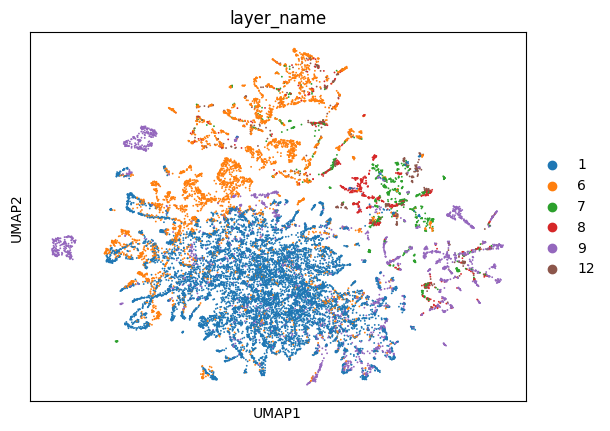

In [171]:
sc.pl.umap(adata_hist, color='layer_name')

In [172]:
stat_json     = "outputs/GP1/ckpt/exp_decoder_full/decoder_counts_normal_cancer.json"
ckpt_path_dec = "outputs/GP1/ckpt/exp_decoder_full/decoder_counts_normal_cancer.pt"

In [173]:
save_dir = f"outputs/GP1/perturb/perturb_results"
device = "cuda:0" if torch.cuda.is_available() else "cpu"
sample_key = "frame"
latent_obsm_key = "X_latent"
batch = 4096
adata_roll = adata_hist
os.makedirs(save_dir, exist_ok=True)

# -----------------------
# Load decoder cfg + build decoder
# -----------------------
with open(stat_json, "r") as f:
    cfg = json.load(f)

genes_all = list(map(str, adata_ori.var_names))
if len(genes_all) == 0:
    raise ValueError("adata_ori.var_names is empty")

# training decoder output
if "genes" in cfg and len(cfg["genes"]) > 0:
    genes_model = [str(g) for g in cfg["genes"]]
else:
    genes_model = genes_all

if len(genes_model) != len(genes_all):
    raise ValueError(
        f"genemismatch:train={len(genes_model)} vs adata_ori={len(genes_all)}"
    )

if set(genes_model) != set(genes_all):
    miss1 = pd.Index(genes_model).difference(pd.Index(genes_all)).tolist()[:10]
    miss2 = pd.Index(genes_all).difference(pd.Index(genes_model)).tolist()[:10]
    raise ValueError(
        f"traininggene adata_ori genemismatch\n"
        f"train-only: {miss1}\n"
        f"adata-only: {miss2}"
    )

in_dim   = int(cfg.get("in_dim", 10))
out_dim  = int(cfg.get("out_dim", len(genes_model)))
h        = tuple(cfg.get("h", (256, 256)))
dropout  = float(cfg.get("dropout", 0.2))
noise_in = float(cfg.get("noise_in", 0.0))
noise_h  = float(cfg.get("noise_h", 0.0))

if out_dim != len(genes_model):
    raise ValueError(
        f"out_dim mismatch: json out_dim={out_dim} vs len(genes_model)={len(genes_model)}"
    )

model_dec = NoisyCountDecoder(
    in_dim=in_dim,
    out_dim=out_dim,
    h=h,
    dropout=dropout,
    noise_in=noise_in,
    noise_h=noise_h,
).to(device)

sd = torch.load(ckpt_path_dec, map_location=device)
model_dec.load_state_dict(sd, strict=True)
model_dec.eval()

# -----------------------
# helpers
# -----------------------
def _get_coords(sub: ad.AnnData) -> np.ndarray:
    if "spatial" in sub.obsm:
        c = sub.obsm["spatial"]
        return c if isinstance(c, np.ndarray) else np.asarray(c)
    if {"cx", "cy"}.issubset(sub.obs.columns):
        return sub.obs[["cx", "cy"]].to_numpy(np.float32)
    raise KeyError("coordinates:requires sub.obsm['spatial']  sub.obs[['cx','cy']]")

def _get_uid_safe(sub: ad.AnnData, N: int) -> np.ndarray:
    if "uid" in sub.obs.columns:
        u = sub.obs["uid"].astype(str).to_numpy()
    else:
        u = pd.Index(sub.obs_names).astype(str).to_numpy()
    u = np.asarray(u).reshape(-1)
    if u.shape[0] != N:
        u = pd.Index(sub.obs_names).astype(str).to_numpy()
        u = np.asarray(u).reshape(-1)
        if u.shape[0] != N:
            raise ValueError(f"uid length mismatch:len(uid)={u.shape[0]} vs N={N}")
    return u

# -----------------------
# iterate samples
# -----------------------
if sample_key not in adata_roll.obs.columns:
    raise KeyError(f"adata.obs missing '{sample_key}'")

svals = adata_roll.obs[sample_key].astype(str).values
uniq = sorted(set(svals), key=lambda x: int(x) if str(x).isdigit() else str(x))

out_paths = []

for sid in uniq:
    mask = (adata_roll.obs[sample_key].astype(str).values == str(sid))
    sub = adata_roll[mask].copy()

    if latent_obsm_key not in sub.obsm:
        raise KeyError(f"sub.obsm missing '{latent_obsm_key}'")

    Z = np.asarray(sub.obsm[latent_obsm_key], dtype=np.float32)
    Zt = torch.as_tensor(Z, device=device, dtype=torch.float32)
    cxy = _get_coords(sub).astype(np.float32)

    N = int(Zt.shape[0])
    if cxy.shape[0] != N:
        raise ValueError(f"coords count mismatch: {cxy.shape[0]} vs {N}")
    if Zt.shape[1] != in_dim:
        raise ValueError(f"latent dim mismatch: Z dim={Zt.shape[1]} vs decoder in_dim={in_dim}")

    # ===== decode in chunks: full-gene counts =====
    pred_chunks = []
    with torch.no_grad():
        for i in range(0, N, batch):
            zchunk = Zt[i:i + batch]
            pred = model_dec(zchunk)   # (B, G_all)
            pred_chunks.append(torch.clamp(pred, min=0.0).cpu().numpy())

    X_pred = np.vstack(pred_chunks).astype(np.float32)

    # ===== obs meta =====
    obs_meta = sub.obs.copy()
    obs_meta["uid"] = _get_uid_safe(sub, N)
    obs_meta.index.name = None
    obs_meta["frame"] = int(sid) if str(sid).isdigit() else str(sid)
    obs_meta["x_roll"] = cxy[:, 0].astype(np.float32)
    obs_meta["y_roll"] = cxy[:, 1].astype(np.float32)

    # ===== build AnnData =====
    adt = ad.AnnData(
        X=X_pred,
        obs=obs_meta,
        var=pd.DataFrame(index=pd.Index(genes_model, name=None)),
        dtype=np.float32,
    )

    adt.layers["counts_hat"] = X_pred.astype(np.float32, copy=False)
    adt.obsm["spatial"] = cxy
    adt.obsm[latent_obsm_key] = np.asarray(sub.obsm[latent_obsm_key], dtype=np.float32)

    adt.uns["sample"] = str(sid)
    adt.obs.index.name = None

    out_path = os.path.join(
        save_dir,
        f"counts_pred_sample{int(sid):02d}.h5ad" if str(sid).isdigit() else f"counts_pred_sample_{sid}.h5ad"
    )
    adt.write(out_path)
    out_paths.append(out_path)

print(f">> Saved {len(out_paths)} files to: {save_dir}")
print(out_paths[:3], "..." if len(out_paths) > 3 else "")

/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  re

>> Saved 101 files to: /home/zhouyj/project/src/GP1/perturb/perturb_results
['/home/zhouyj/project/src/GP1/perturb/perturb_results/counts_pred_sample00.h5ad', '/home/zhouyj/project/src/GP1/perturb/perturb_results/counts_pred_sample01.h5ad', '/home/zhouyj/project/src/GP1/perturb/perturb_results/counts_pred_sample02.h5ad'] ...


/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)


In [174]:
save_dir = f"outputs/GP1/perturb/perturb_results"
# save_dir = f"outputs/GP1/results/rollout_h5ad_gp1"
files = sorted(glob.glob(os.path.join(save_dir, "*.h5ad")))
adatas = {}
for path in files:
    filename = os.path.basename(path)
    sample_id = os.path.splitext(filename)[0]  
    sample_adata = sc.read_h5ad(path)
    sample_adata.var_names_make_unique()
    adatas[sample_id] = sample_adata

adata = ad.concat(adatas, label="sample")
adata.obs_names_make_unique()

print(adata.obs["sample"].value_counts())
adata

sample
counts_pred_sample100    246
counts_pred_sample99     245
counts_pred_sample98     243
counts_pred_sample97     242
counts_pred_sample96     240
                        ... 
counts_pred_sample04     106
counts_pred_sample03     104
counts_pred_sample02     103
counts_pred_sample01     101
counts_pred_sample00     100
Name: count, Length: 101, dtype: int64


AnnData object with n_obs × n_vars = 17494 × 36601
    obs: 'frame', 'uid', 'parent_uid', 'born_step', 'anchor', 'layer_idx', 'layer_name', 'is_diff', 'diff_alpha', 'diff_mid', 'late_prob', 'diff_tgt_layer_idx', 'diff_tgt_layer_name', 'diff_enter_step', 'commit_step', 'lr', 'x_roll', 'y_roll', 'sample'
    obsm: 'X_latent', 'spatial'
    layers: 'counts_hat'

In [178]:
# save_dir = f"outputs/GP1/perturb/perturb_results"
save_dir = f"outputs/GP1/results/rollout_h5ad_gp1"
files = sorted(glob.glob(os.path.join(save_dir, "*.h5ad")))
adatas = {}
for path in files:
    filename = os.path.basename(path)
    sample_id = os.path.splitext(filename)[0]  
    sample_adata = sc.read_h5ad(path)
    sample_adata.var_names_make_unique()
    adatas[sample_id] = sample_adata

adata1 = ad.concat(adatas, label="sample")
adata1.obs_names_make_unique()

print(adata.obs["sample"].value_counts())
adata1

sample
counts_pred_sample100    246
counts_pred_sample99     245
counts_pred_sample98     243
counts_pred_sample97     242
counts_pred_sample96     240
                        ... 
counts_pred_sample04     106
counts_pred_sample03     104
counts_pred_sample02     103
counts_pred_sample01     101
counts_pred_sample00     100
Name: count, Length: 101, dtype: int64


/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 19728 × 0
    obs: 'cx', 'cy', 'layer_idx', 'layer_name', 'uid', 'parent_uid', 'is_birth', 'is_diff', 'diff_alpha', 'diff_tgt_layer', 'diff_tgt_layer_name', 'sample'
    obsm: 'X_latent', 'spatial'

In [179]:
frame_str = adata.obs["sample"].astype(str)

adata.obs["t"] = (
    frame_str
    .str.extract(r"sample(\d+)$", expand=False)
    .astype(int)
) 

In [180]:
frame_str = adata1.obs["sample"].astype(str)

adata1.obs["t"] = (
    frame_str
    .str.extract(r"_f(\d+)_t", expand=False)
    .astype(int)
)

/tmp/ipykernel_2713963/4014945765.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


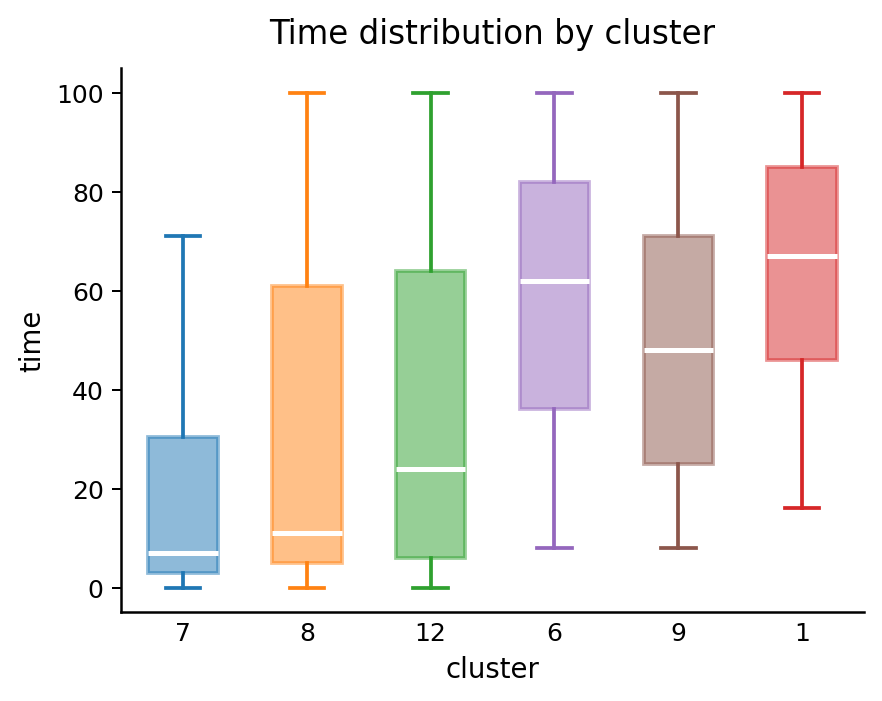

In [177]:
def plot_time_boxplot_by_cluster(
    adata,
    cluster_col="cluster",
    time_col="time",
    cluster_order=("7", "8", "12", "6", "9", "1"),
    showfliers=False,
    figsize=(5, 4),
    dpi=180,
):
    obs = adata.obs.copy()

    def get_1d_col(df, col):
        x = df[col]
        if isinstance(x, pd.DataFrame):
            print(f"[warn] {col!r} has duplicated columns,using first column")
            x = x.iloc[:, 0]
        return x

    clu = get_1d_col(obs, cluster_col).astype(str)
    tim = pd.to_numeric(get_1d_col(obs, time_col), errors="coerce")

    df = pd.DataFrame({
        "cluster": clu,
        "time": tim
    }).dropna()

    cluster_order = [str(x) for x in cluster_order]

    # here 0  3
    exclude_clusters = {}
    present_order = [
        c for c in cluster_order
        if c in df["cluster"].unique() and c not in exclude_clusters
    ]

    if len(present_order) == 0:
        raise ValueError(" cluster  adata.obs find.")

    data_list = [
        df.loc[df["cluster"] == c, "time"].values
        for c in present_order
    ]

    color_map = {
        "7": "#1F77B4",
        "8": "#FF8212",
        "12": "#2FA12F",
        "1": "#D62728",
        "6": "#9467BD",
        "9": "#8C564B",
    }

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    bp = ax.boxplot(
        data_list,
        labels=present_order,
        patch_artist=True,
        widths=0.56,
        showfliers=showfliers,
        medianprops=dict(color="white", linewidth=2.0),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        boxprops=dict(linewidth=1.5),
    )

    for i, c in enumerate(present_order):
        col = color_map.get(c, "#bdbdbd")

        bp["boxes"][i].set_facecolor(col)
        bp["boxes"][i].set_edgecolor(col)
        bp["boxes"][i].set_alpha(0.5)

        bp["whiskers"][2 * i].set_color(col)
        bp["whiskers"][2 * i + 1].set_color(col)

        bp["caps"][2 * i].set_color(col)
        bp["caps"][2 * i + 1].set_color(col)

        bp["medians"][i].set_color("white")
        bp["medians"][i].set_linewidth(2.0)

    ax.set_xlabel("cluster", fontsize=11)
    ax.set_ylabel("time", fontsize=11)
    ax.set_title("Time distribution by cluster", fontsize=13, pad=10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)

    ax.tick_params(axis="x", labelsize=10, length=0)
    ax.tick_params(axis="y", labelsize=10)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.0)

    plt.tight_layout()
    plt.show()

    return df

df_time_plot = plot_time_boxplot_by_cluster(
    adata,
    cluster_col="layer_name",
    time_col="t",
    showfliers=False,
)

In [193]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from matplotlib.patches import Patch

def plot_time_compare_merged_before_after(
    adata_after,
    adata_before,
    cluster_col="layer_name",
    time_col="t",
    clusters=("8", "12"),
    group_names=("Before", "After"),
    showfliers=False,
    figsize=(4.2, 4),
    dpi=180,
    alternative="greater",   # after > before
):
    def get_1d_col(df, col):
        x = df[col]
        if isinstance(x, pd.DataFrame):
            print(f"[warn] {col!r} has duplicated columns,using first column")
            x = x.iloc[:, 0]
        return x

    def build_df(ad, label):
        obs = ad.obs.copy()
        clu = get_1d_col(obs, cluster_col).astype(str)
        tim = pd.to_numeric(get_1d_col(obs, time_col), errors="coerce")
        out = pd.DataFrame({
            "cluster": clu,
            "time": tim,
            "group": label
        }).dropna()
        return out

    before_label, after_label = group_names
    clusters = [str(x) for x in clusters]

    df_before = build_df(adata_before, before_label)
    df_after  = build_df(adata_after,  after_label)

    df = pd.concat([df_before, df_after], axis=0, ignore_index=True)
    df = df[df["cluster"].isin(clusters)].copy()

    if df.empty:
        raise ValueError("missing, cluster_col / time_col / clusters.")

    x_before = df.loc[df["group"] == before_label, "time"].to_numpy()
    x_after  = df.loc[df["group"] == after_label,  "time"].to_numpy()

    if len(x_before) == 0 or len(x_after) == 0:
        raise ValueError("Before  After missing.")

    if alternative == "greater":
        U, p = mannwhitneyu(x_before, x_after, alternative="less")   # after > before
    elif alternative == "less":
        U, p = mannwhitneyu(x_before, x_after, alternative="greater")
    else:
        U, p = mannwhitneyu(x_before, x_after, alternative="two-sided")

    stat_df = pd.DataFrame([{
        "clusters_merged": ",".join(clusters),
        "n_before": len(x_before),
        "n_after": len(x_after),
        "median_before": np.median(x_before),
        "median_after": np.median(x_after),
        "delta_median": np.median(x_after) - np.median(x_before),
        "U": U,
        "pvalue": p,
    }])

    color_map = {
        before_label: "#9E9E9E",
        after_label:  "#E64B35",
    }

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    fig.patch.set_alpha(0)
    ax.set_facecolor("none")

    data = [x_before, x_after]
    positions = [1, 2]

    bp = ax.boxplot(
        data,
        positions=positions,
        widths=0.5,
        patch_artist=True,
        showfliers=showfliers,
        medianprops=dict(color="white", linewidth=2.0),
        whiskerprops=dict(linewidth=1.4),
        capprops=dict(linewidth=1.4),
        boxprops=dict(linewidth=1.4),
    )

    for box, col in zip(bp["boxes"], [color_map[before_label], color_map[after_label]]):
        box.set_facecolor(col)
        box.set_edgecolor(col)
        box.set_alpha(0.8)

    for i, w in enumerate(bp["whiskers"]):
        w.set_color(color_map[before_label] if i < 2 else color_map[after_label])
    for i, c in enumerate(bp["caps"]):
        c.set_color(color_map[before_label] if i < 2 else color_map[after_label])
    for med in bp["medians"]:
        med.set_color("white")
        med.set_linewidth(2.0)

    def fmt_p(p):
        if pd.isna(p):
            return "p = NA"
        if p < 1e-4:
            return "p < 1e-4"
        return f"p = {p:.3g}"

    ymax = max(np.max(x_before), np.max(x_after))
    ymin = min(np.min(x_before), np.min(x_after))
    yr = ymax - ymin if ymax > ymin else 1.0
    y = ymax + 0.06 * yr
    h = 0.03 * yr

    ax.plot([1, 1, 2, 2], [y, y + h, y + h, y], lw=1.2, c="black")
    ax.text(1.5, y + h + 0.01 * yr, fmt_p(p), ha="center", va="bottom", fontsize=9)

    ax.set_xticks([1, 2])
    ax.set_xticklabels([before_label, after_label])
    ax.set_ylabel("time", fontsize=11)
    ax.set_xlabel("")
    ax.set_title("Merged clusters 8+12: Before vs After", fontsize=13, pad=10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)
    ax.tick_params(axis="x", labelsize=10, length=0)
    ax.tick_params(axis="y", labelsize=10)

    plt.tight_layout()
    plt.show()

    return df, stat_df

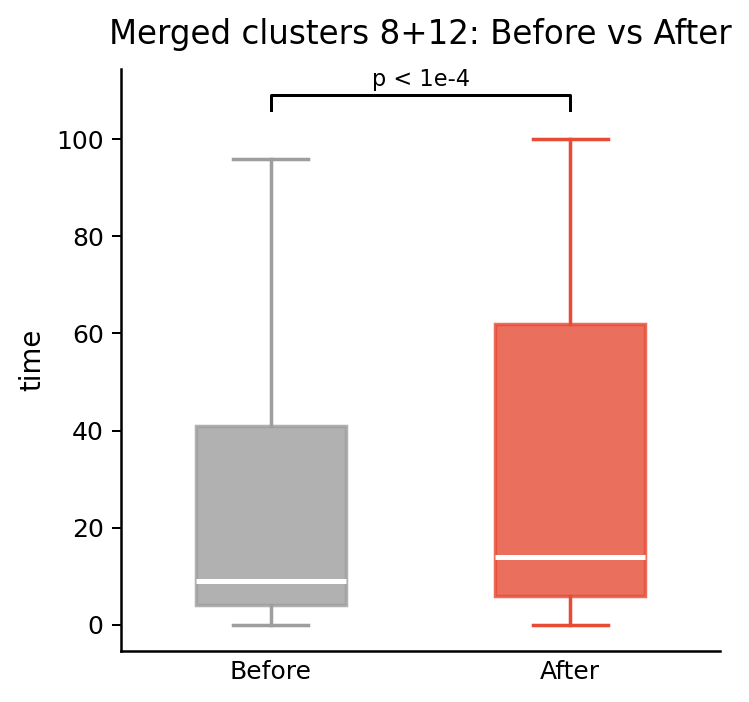

In [194]:
df_merge, stat_merge = plot_time_compare_merged_before_after(
    adata_after=adata,
    adata_before=adata1,
    cluster_col="layer_name",   #  "cluster"
    time_col="t",
    clusters=("8", "12"),
    group_names=("Before", "After"),
    showfliers=False,
    alternative="greater",
)